**Loading Data File**

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('mtfuji_data.csv')
elevation_data = data['elevation'].values
point_numbers = np.arange(len(elevation_data))

**[Problem 1]: Data Visualization**

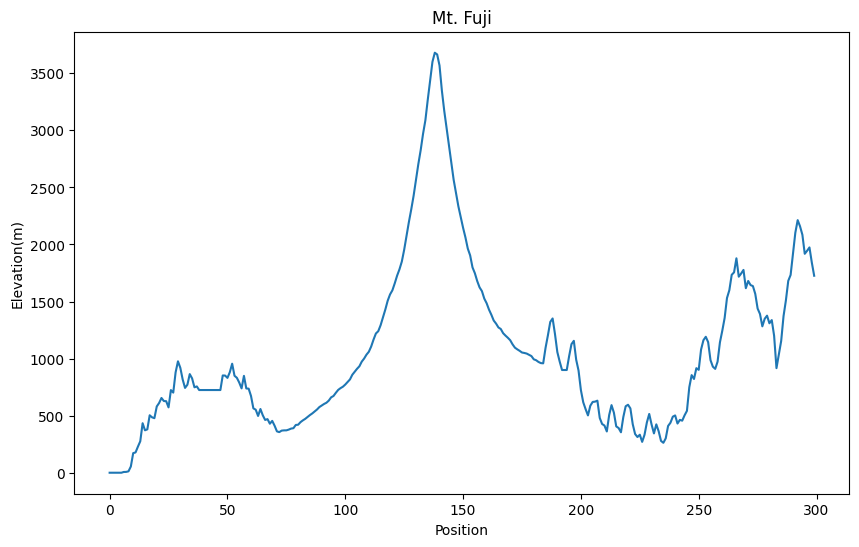

In [6]:
fig, ax = plt.subplots(figsize = (10,6))
ax.plot(point_numbers, elevation_data)

ax.set_xlabel('Position')
ax.set_ylabel('Elevation(m)')
ax.set_title('Mt. Fuji')

plt.show()

**[Problem 2]: Create a function to calculate the gradient at a certain point**

In [7]:
import numpy as np

def calculate_gradients(elevation_data):
    gradients = np.diff(elevation_data)
    return gradients

# Example usage
elevation_data = np.array([0, 0, 0, 0, 0, 6.62, 7.21, 12.2, 54.41, 171.56])
gradients = calculate_gradients(elevation_data)
print("Gradients: ",gradients)

Gradients:  [  0.     0.     0.     0.     6.62   0.59   4.99  42.21 117.15]


**[Problem 3]: Create a function to calculate the destination point**

In [11]:
# Define the function to calculate the next destination point
def calculate_next_destination_point(current_point, gradients, alpha=0.2):
    if not isinstance(current_point, int):
        raise ValueError("Current point must be an integer.")

    if current_point < 0 or current_point >= len(gradients):
        raise ValueError("Current point is out of bounds.")

    gradient = gradients[current_point]
    next_point = current_point - alpha * gradient
    next_point = round(next_point)

    if next_point < 0:
        next_point = 0
    elif next_point >= len(gradients):
        next_point = len(gradients) - 1

    return next_point


# Example usage
current_point = 10
next_point = calculate_next_destination_point(current_point, gradients)
print(f"Next destination point: {next_point}")

Next destination point: 9


**[Problem 4]: Create a function to go down a mountain**

In [12]:
# Define the function to simulate descending the mountain
def descend_mountain(initial_point, gradients):
    path = [initial_point]
    current_point = initial_point

    while True:
        next_point = calculate_next_destination_point(current_point, gradients)

        if next_point == current_point:
            break

        path.append(next_point)
        current_point = next_point

    return path


# Example usage
initial_point = 136 # Near the summit
path = descend_mountain(initial_point, gradients)
print("Descent Path: ", path)

Descent Path:  [136, 103, 98, 95, 89, 86, 83, 80, 76, 74]


**[Problem 5]: Visualization of the descent process**

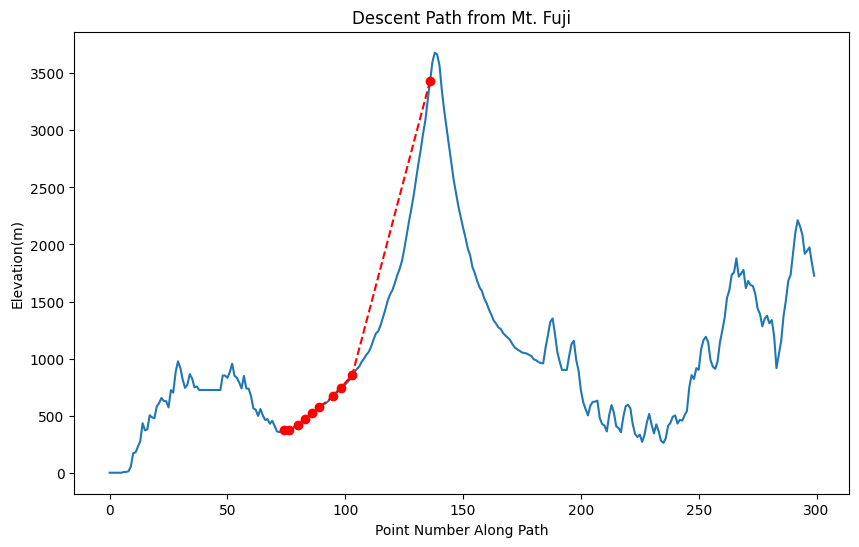

In [15]:
# Create a figure and axis
fig, ax = plt.subplots(figsize = (10, 6))

# Plot elevation data
ax.plot(elevation_data)

# Highlight the descent path
ax.plot(path, [elevation_data[i] for i in path], marker = 'o', linestyle = '--', color = 'red')

# Set labels and title
ax.set_xlabel('Point Number Along Path')
ax.set_ylabel('Elevation(m)')
ax.set_title('Descent Path from Mt. Fuji')

# Show the plot
plt.show()

**[Problem 6]: Changing the initial value**

In [21]:
# Example usage for different initial points
initial_points = [10, 50, 100, 136]

for initial_point in initial_points:
    path = descend_mountain(initial_point, gradients)
    print(f"Descent Path from Point {initial_point}: {path}")

Descent Path from Point 10: [10, 9, 0]
Descent Path from Point 50: [50, 40]
Descent Path from Point 100: [100, 95, 89, 86, 83, 80, 76, 74]
Descent Path from Point 136: [136, 103, 98, 95, 89, 86, 83, 80, 76, 74]


**[Problem 7]: Visualization of the descent process for each initial value**

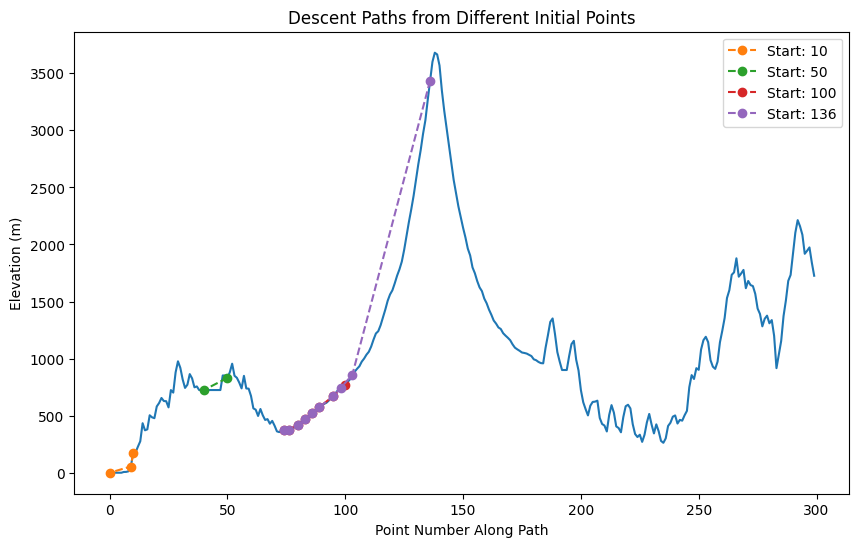

In [22]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot elevation data
ax.plot(elevation_data)

# Highlight the descent paths for different initial points
for initial_point in initial_points:
    path = descend_mountain(initial_point, gradients)
    ax.plot(path, [elevation_data[i] for i in path], marker='o', linestyle='--', label=f"Start: {initial_point}")

# Set labels and title
ax.set_xlabel('Point Number Along Path')
ax.set_ylabel('Elevation (m)')
ax.set_title('Descent Paths from Different Initial Points')
ax.legend()

# Show the plot
plt.show()

**[Problem 8]: (Advanced problem) Changing hyperparameters**

Next destination point: 9
Descent Path:  [136, 119, 115, 108, 105, 103, 100, 98, 97, 95, 92, 90, 89, 88, 86, 84, 82, 81, 79]


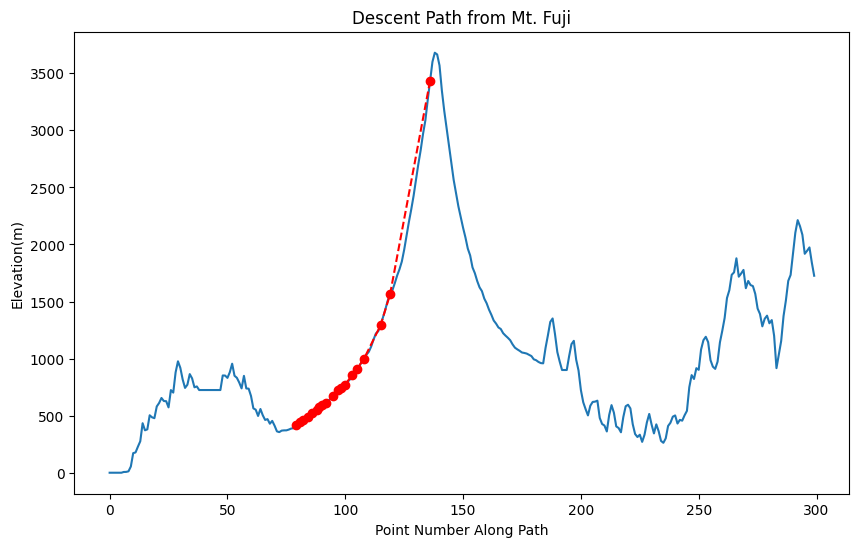

In [27]:
# Define the function to calculate the next destination point
def calculate_next_destination_point(current_point, gradients, alpha=0.1):
    if not isinstance(current_point, int):
        raise ValueError("Current point must be an integer.")

    if current_point < 0 or current_point >= len(gradients):
        raise ValueError("Current point is out of bounds.")

    gradient = gradients[current_point]
    next_point = current_point - alpha * gradient
    next_point = round(next_point)

    if next_point < 0:
        next_point = 0
    elif next_point >= len(gradients):
        next_point = len(gradients) - 1

    return next_point


# Example usage
current_point = 10
next_point = calculate_next_destination_point(current_point, gradients)
print(f"Next destination point: {next_point}")


# Define the function to simulate descending the mountain
def descend_mountain(initial_point, gradients):
    path = [initial_point]
    current_point = initial_point

    while True:
        next_point = calculate_next_destination_point(current_point, gradients)

        if next_point == current_point:
            break

        path.append(next_point)
        current_point = next_point

    return path


# Example usage
initial_point = 136 # Near the summit
path = descend_mountain(initial_point, gradients)
print("Descent Path: ", path)


# Create a figure and axis
fig, ax = plt.subplots(figsize = (10, 6))

# Plot elevation data
ax.plot(elevation_data)

# Highlight the descent path
ax.plot(path, [elevation_data[i] for i in path], marker = 'o', linestyle = '--', color = 'red')

# Set labels and title
ax.set_xlabel('Point Number Along Path')
ax.set_ylabel('Elevation(m)')
ax.set_title('Descent Path from Mt. Fuji')

# Show the plot
plt.show()